In [1]:
import os 
import subprocess

from datasets import load_dataset
from dotenv import load_dotenv
import numpy as np 
from sklearn.manifold import TSNE 
import matplotlib.pyplot as plt 
import scienceplots 

load_dotenv()

DATA_ROOT = os.getenv("DATA_ROOT")
plt.style.use("science")

latex_bin_path = f"{DATA_ROOT}/texlive_store/texlive/bin/x86_64-linux"
os.environ["PATH"] = latex_bin_path + os.pathsep + os.environ["PATH"]

try:
    version = subprocess.check_output(["latex", "--version"]).decode().splitlines()[0]
    print(f"Using LaTeX version: {version}")
except Exception as e:
    print(f"Error finding LaTeX: {e}")

# Now enable LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

/data/dtce-schmidt/phys2526/venvs/wwdc_spectra/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using LaTeX version: pdfTeX 3.141592653-2.6-1.40.28 (TeX Live 2025)


# Spender I

In [2]:
fp = f"{DATA_ROOT}/sdss_II/spender_I_flow_v2/embeddings/7655991_0"

data_files = {
    "train": f"{fp}/train/*.parquet",
    "val":  f"{fp}/val/*.parquet",
    "test": f"{fp}/test/*.parquet"
}
ds = load_dataset(
    "parquet",
    data_files=data_files
)

In [3]:
filtered_ds = ds["test"].filter(lambda example: example["mask_ratio"] != 1.0)
total_test_rows = filtered_ds.num_rows
print(f"Rows remaining after filtering: {total_test_rows}")
filtered_ds.set_format(type="numpy", columns=["orig", "cond", "uncond", "z"])
features = {
    "orig": np.array(filtered_ds["orig"]).reshape(total_test_rows, -1),
    "cond": np.array(filtered_ds["cond"]).reshape(total_test_rows, -1),
}
z_values = np.array(filtered_ds["z"])

Rows remaining after filtering: 51492


In [4]:
labels = {
    "orig": "Original (Spender I)",
    'cond': "WWDC (Ours)"
}

Loading saved t-SNE for 'orig' from ./tsne_embeddings/tsne_orig_51492.npy...


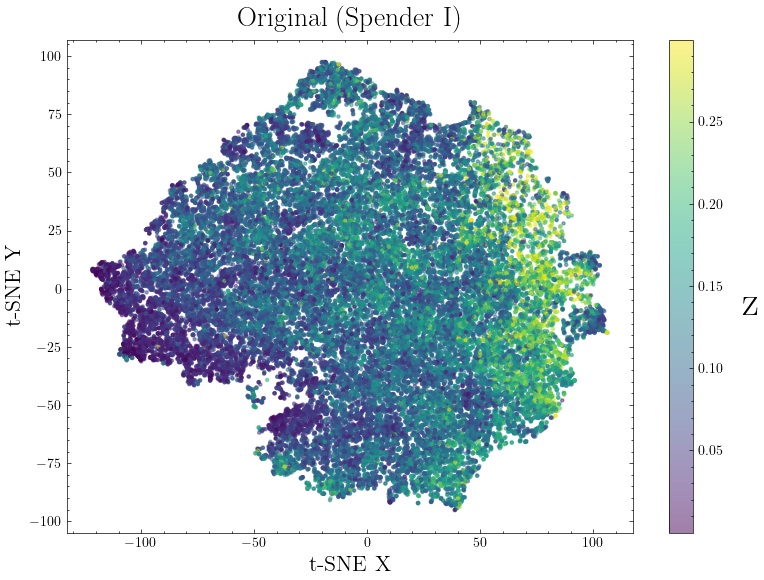

Loading saved t-SNE for 'cond' from ./tsne_embeddings/tsne_cond_51492.npy...


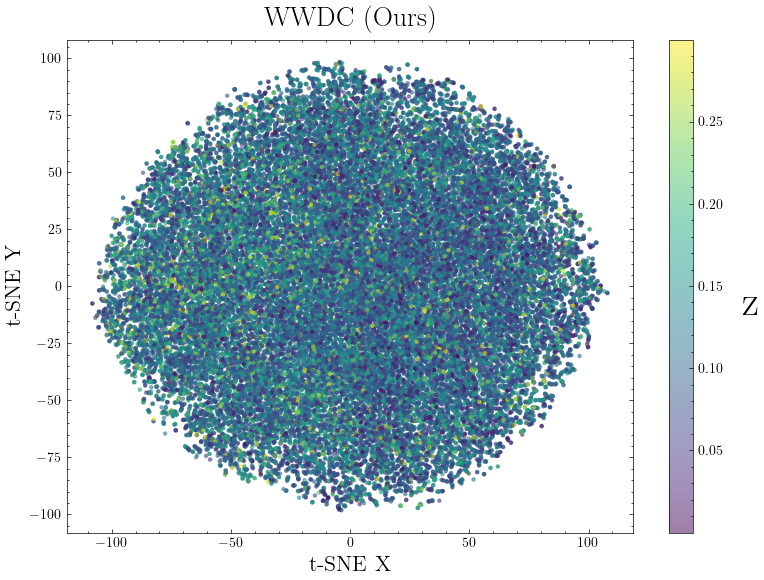

In [5]:
# 1. Create a boolean mask for z <= 0.3
mask = z_values <= 0.3
filtered_z = z_values[mask]

# Create the directory if it doesn't exist
save_dir = "./tsne_embeddings"
os.makedirs(save_dir, exist_ok=True)

# Compute/Load and plot t-SNE for each feature in separate figures
for name, data in features.items():
    
    # Create a new figure and axis for this specific feature
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Define a unique filename for each feature using the total rows
    file_path = os.path.join(save_dir, f"tsne_{name}_{total_test_rows}.npy")
    
    # Check if the embeddings have already been computed and saved
    if os.path.exists(file_path):
        print(f"Loading saved t-SNE for '{name}' from {file_path}...")
        tsne_results = np.load(file_path)
    else:
        print(f"Computing t-SNE for '{name}'...")
        # Initialize and fit t-SNE on the full data
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
        tsne_results = tsne.fit_transform(data)
        
        # Save the computed embeddings to disk
        print(f"Saving t-SNE for '{name}' to {file_path}...")
        np.save(file_path, tsne_results)
    
    # 2. Apply the mask to the loaded/computed t-SNE results
    filtered_tsne = tsne_results[mask]
    
    # Scatter plot with color coding using only the filtered points
    scatter = ax.scatter(filtered_tsne[:, 0], filtered_tsne[:, 1], c=filtered_z, cmap='viridis', alpha=0.5, s=5)
    
    ax.set_title(f"{labels[name]}", fontsize=20, pad=10)
    ax.set_xlabel("t-SNE X", fontsize=16)
    ax.set_ylabel("t-SNE Y", fontsize=16)

    # Add a colorbar for this specific plot
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('z', fontsize=30, rotation=0, labelpad=20)
    
    # We can safely use tight_layout now that there is only one plot per figure
    plt.tight_layout()
    plt.show()

# Spender II

In [6]:
fp = f"{DATA_ROOT}/sdss_II/spender_II_flow_v2/embeddings/7655992_0"

data_files = {
    "train": f"{fp}/train/*.parquet",
    "val":  f"{fp}/val/*.parquet",
    "test": f"{fp}/test/*.parquet"
}
ds = load_dataset(
    "parquet",
    data_files=data_files
)

In [7]:
filtered_ds = ds["test"].filter(lambda example: example["mask_ratio"] != 1.0)

total_test_rows = filtered_ds.num_rows
print(f"Rows remaining after filtering: {total_test_rows}")

filtered_ds.set_format(type="numpy", columns=["orig", "cond", "uncond", "z"])

features = {
    "orig": np.array(filtered_ds["orig"]).reshape(total_test_rows, -1),
    "cond": np.array(filtered_ds["cond"]).reshape(total_test_rows, -1),
}

# Extract the 'z' values to use for color coding
z_values = np.array(filtered_ds["z"])

Rows remaining after filtering: 51492


In [8]:
labels = {
    "orig": "Original (Spender II)",
    'cond': "WWDC (Ours)"
}

Loading saved t-SNE for 'orig' from ./tsne_embeddings/tsne_orig_51492_spender_II.npy...


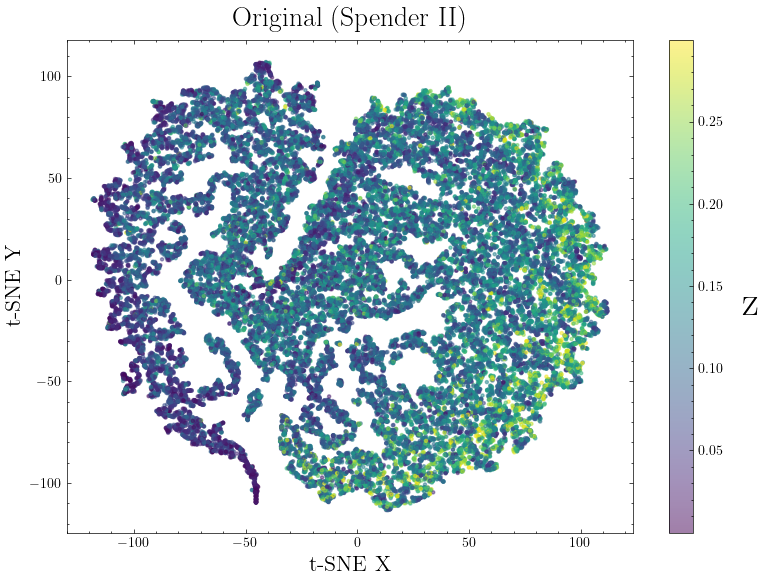

Loading saved t-SNE for 'cond' from ./tsne_embeddings/tsne_cond_51492_spender_II.npy...


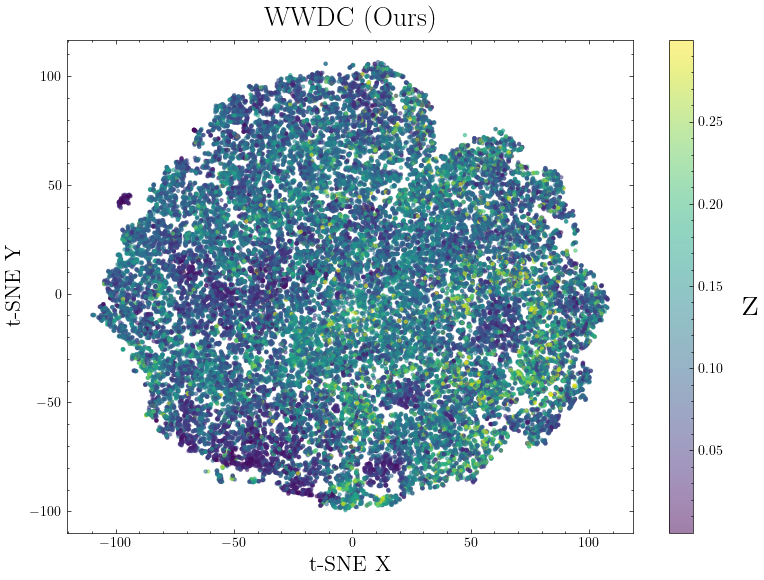

In [9]:
# 1. Create a boolean mask for z <= 0.3
mask = z_values <= 0.3
filtered_z = z_values[mask]

save_dir = "./tsne_embeddings"
os.makedirs(save_dir, exist_ok=True)

for name, data in features.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    
    file_path = os.path.join(save_dir, f"tsne_{name}_{total_test_rows}_spender_II.npy")
    
    if os.path.exists(file_path):
        print(f"Loading saved t-SNE for '{name}' from {file_path}...")
        tsne_results = np.load(file_path)
    else:
        print(f"Computing t-SNE for '{name}'...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
        tsne_results = tsne.fit_transform(data)
        print(f"Saving t-SNE for '{name}' to {file_path}...")
        np.save(file_path, tsne_results)
    
    filtered_tsne = tsne_results[mask]
    
    scatter = ax.scatter(filtered_tsne[:, 0], filtered_tsne[:, 1], c=filtered_z, cmap='viridis', alpha=0.5, s=5)
    
    ax.set_title(f"{labels[name]}", fontsize=20, pad=10)
    ax.set_xlabel("t-SNE X", fontsize=16)
    ax.set_ylabel("t-SNE Y", fontsize=16)

    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('z', fontsize=30, rotation=0, labelpad=20)
    
    plt.tight_layout()
    plt.show()